In [3]:
%run init_notebook.py

Module aliases imported by init_notebook.py:
--------------------------------------------
import numpy as np

import pandas as pd

import statsmodels.formula.api as smf

import pymc as pm

import xarray as xr

import arviz as az

import utils as utils

from scipy import stats as stats

from matplotlib import pyplot as plt

Watermark:
----------
Last updated: 2026-02-01T16:29:28.069817+04:00

Python implementation: CPython
Python version       : 3.10.18
IPython version      : 8.15.0

Compiler    : Clang 20.1.4 
OS          : Darwin
Release     : 25.2.0
Machine     : arm64
Processor   : arm
CPU cores   : 14
Architecture: 64bit

pandas     : 2.1.0
arviz      : 0.16.1
numpy      : 1.24.4
pymc       : 5.8.0
statsmodels: 0.14.0
matplotlib : 3.7.2
scipy      : 1.11.2
xarray     : 2023.8.0



,height,weight,age,male
0,151.765,47.825606,63.0,1
1,139.700,36.485807,63.0,0
2,136.525,31.864838,65.0,0
3,156.845,53.041914,41.0,1
4,145.415,41.276872,51.0,0


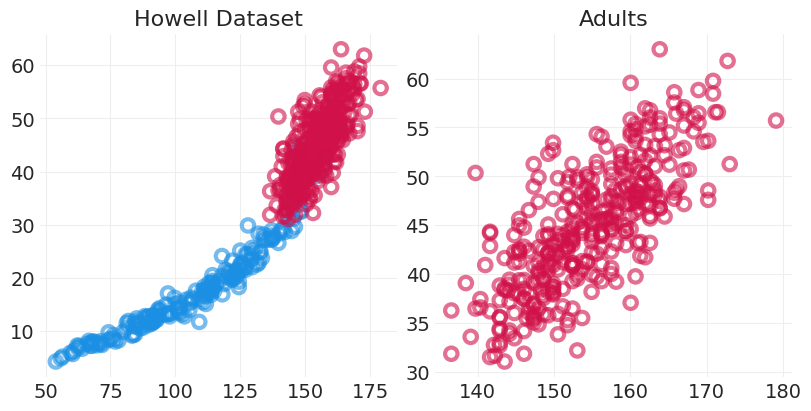

In [4]:
#Importing howell dataset

HOWELL = utils.load_data("Howell1")
fig, axs = plt.subplots(1, 2, figsize=(8, 4))

ADULTS = HOWELL.age >= 18
ADULT_HOWELL = HOWELL[ADULTS]
CHILD_HOWELL = HOWELL[~ADULTS]
plt.sca(axs[0])
utils.plot_scatter(CHILD_HOWELL.height, CHILD_HOWELL.weight, color='C1')
utils.plot_scatter(ADULT_HOWELL.height, ADULT_HOWELL.weight)
plt.title("Howell Dataset")

plt.sca(axs[1])
utils.plot_scatter(ADULT_HOWELL.height, ADULT_HOWELL.weight)
plt.title("Adults")
HOWELL.head()

# Question to address



### (2) Scientific Model
How does **height** influence **weight**?

$$
\begin{align}
H \rightarrow W \\
W = f(H)
\end{align}
$$

i.e. *"Weight is some function of height"*



### (3) Generative Models

Options

1. Dynamic - relationship changes over time
2. Static - constant trend over time

$$W = f(H, U)$$

*"Weight $W$ is a function of height, $H$ and some unobserved stuff, $U$"*

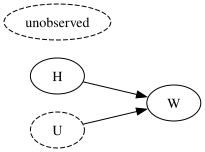

In [5]:
utils.draw_causal_graph(
    edge_list=[
        ("H", "W"),
        ("U", "W")
    ],
    node_props={
        "U": {"style": "dashed"},
        "unobserved": {"style": "dashed"}
    },
    graph_direction="LR"
)

### Linear regression model

We need a function that maps adult weight as a proportion of height plus some unobserved/unaccounted-for causes. Enter **Linear Regression**:

$$W = \beta H + U$$


### Generative model description:
$$
\begin{align}
W_i &\sim \beta H_i + U_i \\
U_i &\sim \text{Normal}(0, \sigma) \\
H_i &\sim \text{Uniform}(130, 170)
\end{align}
$$

### Describing models

- Variables on the left
- Definition on right
- $\sim$ indicates sampling from a distribution
  - e.g. $H_i \sim \text{Uniform}(130, 170)$ is definition that _height is distributed uniformly between 130 and 170_
- $=$ indicates statistical expectation or deterministic equality
  - e.g. $W_i \sim \beta H_i + U_i$ is definition of equation for _expected weight_
- subscripts $i$ indicates index of a observation/individual
- generally code will be written in opposite direction, because you need variables defined in order to be referenced/composed


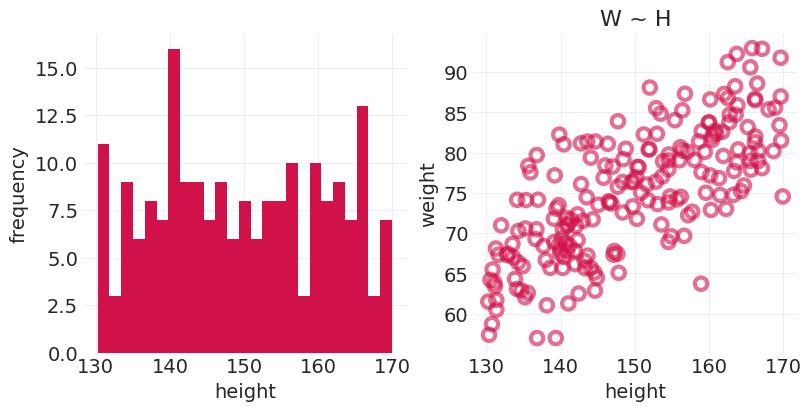

In [6]:
def simulate_weight(H: np.array, beta: float, sigma: float) -> np.ndarray:
    """
    Generative model describe above, simulate weight given height, `H`,
    proportional coefficient `beta`, and the standard deviation of
    unobserved (Normally-distributed) noise, sigma.
    """
    n_heights = len(H)
    
    # unobserved noise
    U = stats.norm.rvs(0, sigma, size=n_heights)
    return beta * H + U

n_heights = 200
MIN_HEIGHT = 130
MAX_HEIGHT = 170
H = stats.uniform.rvs(MIN_HEIGHT, MAX_HEIGHT - MIN_HEIGHT, size=n_heights)
W = simulate_weight(H, beta=0.5, sigma=5)

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
plt.sca(axs[0])
plt.hist(H, bins=25)
plt.xlabel("height")
plt.ylabel("frequency")

plt.sca(axs[1])
utils.plot_scatter(H, W)
plt.xlabel("height")
plt.ylabel("weight")
plt.title("W ~ H");


### Linear Regression

Estimate how the average weight changes with a change in height:

$$E[W_i | H_i] = \alpha + \beta H_i$$

- $E[W_i | H_i]$: **average weight** conditioned on height
- $\alpha$: **intercept** of line
- $\beta$: **slope** of line


### Posterior Distribution

$$
p(\alpha, \beta, \sigma) = \frac{p(W_i | \alpha, \beta, \sigma) p(\alpha, \beta, \sigma)}{Z}
$$

- The only estimator in Bayesian data analysis

- $p(\alpha, \beta, \sigma)$ -- **Posterior**: Probability of a specific line (model)
- $p(W_i | \alpha, \beta, \sigma)$ -- **Likelihood**: The number of ways the generative proces (line) could have produced the data 
    - aka the "Garden of Forking Data" from Lecture 2
- $p(\alpha, \beta, \sigma)$ -- **Prior**: the previous Posterior (sometimes with no data)
- $Z$ -- **normalizing constant**

Common parameterization

$$
\begin{align}
W_i &\sim \text{Normal}(\mu_i, \sigma) \\
\mu_i &= \alpha + \beta H_i
\end{align}
$$

_$W$ is distributed normally with mean $\mu$ that is a linear function of $H$_

In [7]:
# Model function required for simulation
def linear_model(x: np.ndarray, intercept: float, slope: float) -> np.ndarray:
    return intercept + slope * x

# Posterior function required for simulation
def linear_regression_posterior(
    x_obs: np.ndarray,
    y_obs: np.ndarray,
    intercept_grid: np.ndarray,
    slope_grid: np.ndarray,
    likelihood_prior_std: float = 1.0
) -> np.ndarray:
    
    # Convert params to 1-d arrays
    if np.ndim(intercept_grid) > 1:
        intercept_grid = intercept_grid.ravel()
    
    if np.ndim(slope_grid):
        slope_grid = slope_grid.ravel()
    
    log_prior_intercept = stats.norm(0, 1).logpdf(intercept_grid)
    log_prior_slope = stats.norm(0, 1).logpdf(slope_grid)
    
    log_likelihood = np.array(
        [
            stats.norm(
                intercept + slope * x_obs,
                likelihood_prior_std
            ).logpdf(y_obs) for intercept, slope in zip(intercept_grid, slope_grid)
        ]
    ).sum(axis=1)
    
    # Posterior is equal to the product of likelihood and priors (here a sum in log scale)
    log_posterior = log_likelihood + log_prior_intercept + log_prior_slope

    # Convert back to natural scale
    return np.exp(log_posterior - log_posterior.max())

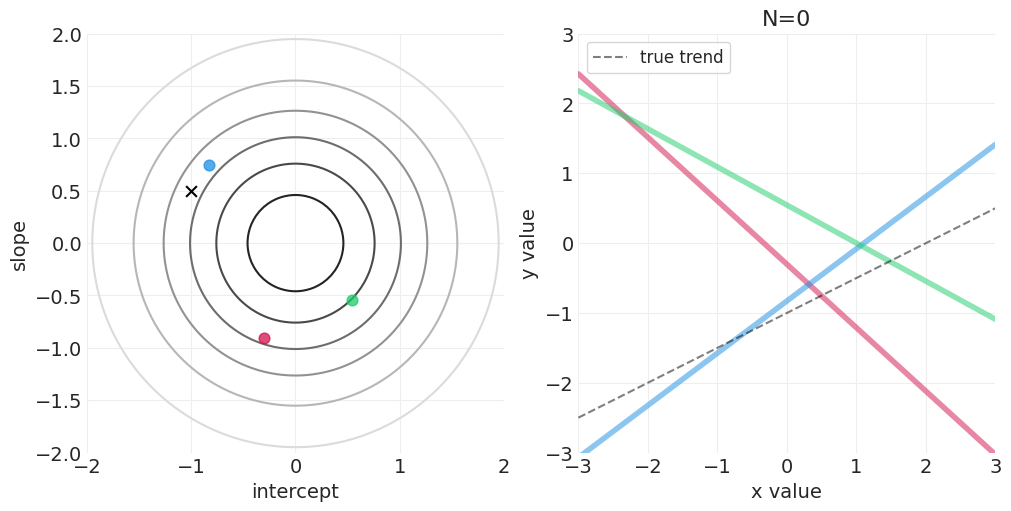

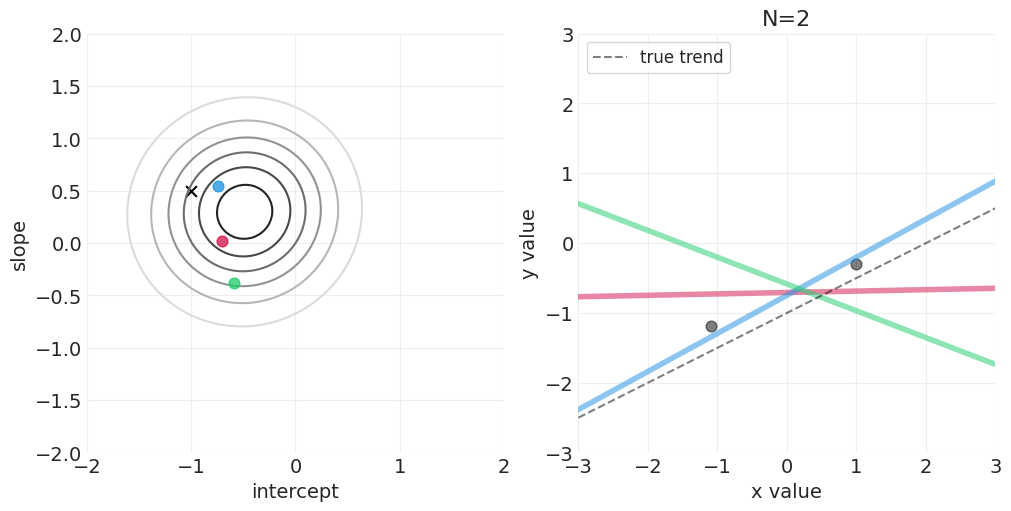

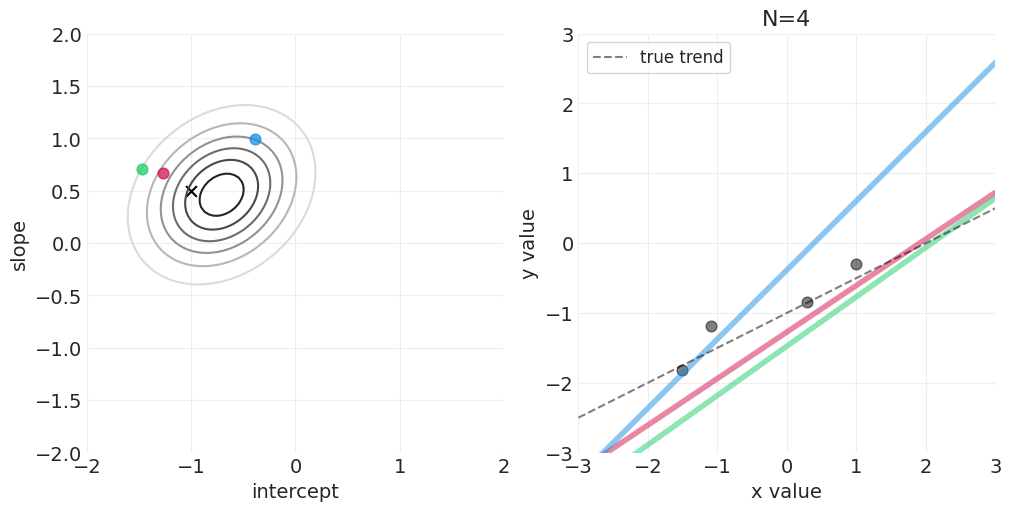

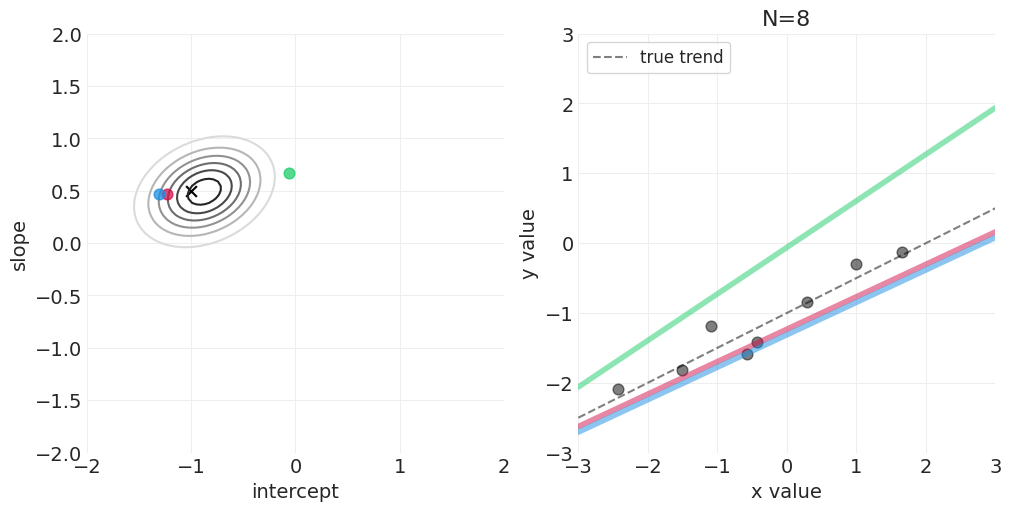

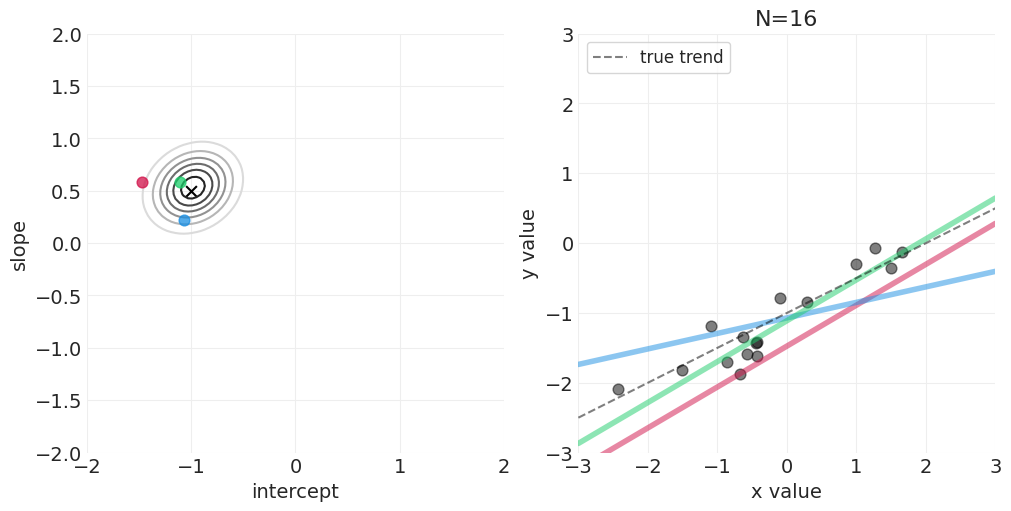

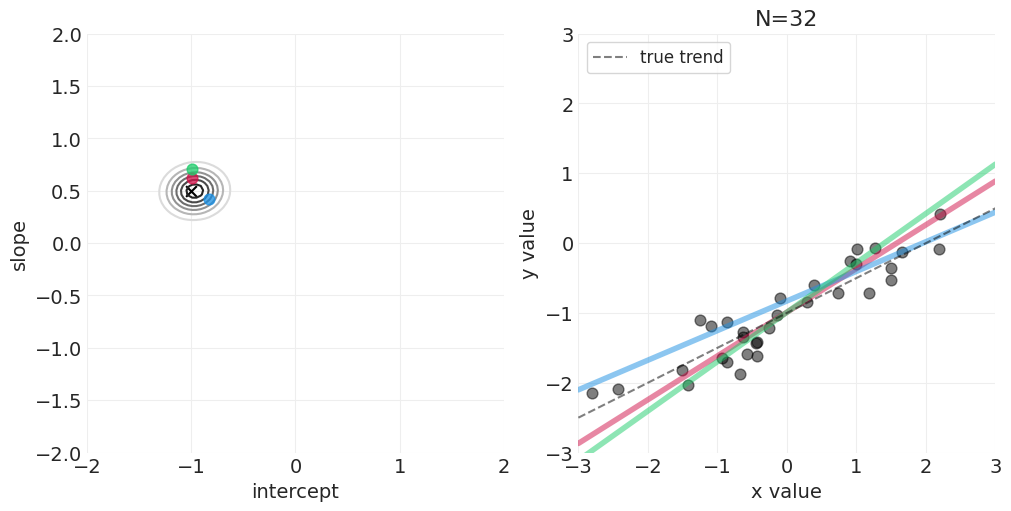

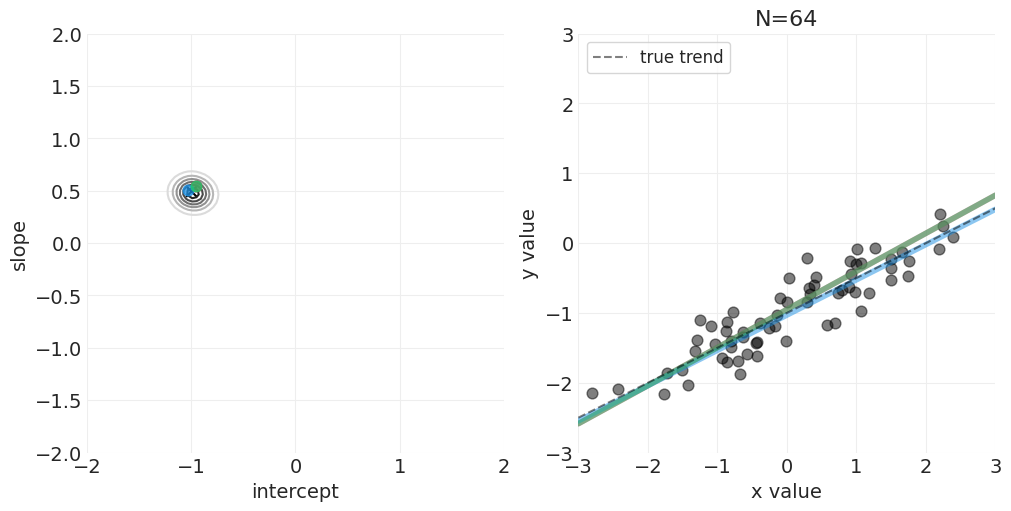

In [8]:
# Generate standardized regression data for demo
np.random.seed(123)
RESOLUTION = 100
N_DATA_POINTS = 64

# Ground truth parameters
SLOPE = 0.5
INTERCEPT = -1

x = stats.norm().rvs(size=N_DATA_POINTS)
y = INTERCEPT + SLOPE * x + stats.norm.rvs(size=N_DATA_POINTS) * 0.25

slope_grid = np.linspace(-2, 2, RESOLUTION)
intercept_grid = np.linspace(-2, 2, RESOLUTION)

# Vary the sample size to show how the posterior adapts to more and more data
for n_samples in [0, 2, 4, 8, 16, 32, 64]:
    # Run the simulation
    utils.simulate_2_parameter_bayesian_learning_grid_approximation(
        x_obs=x[:n_samples],
        y_obs=y[:n_samples],
        param_a_grid=intercept_grid,
        param_b_grid=slope_grid,
        true_param_a=INTERCEPT,
        true_param_b=SLOPE,
        model_func=linear_model,
        posterior_func=linear_regression_posterior,
        param_labels=['intercept', 'slope'],
        data_range_x=(-3, 3), data_range_y=(-3, 3)
    )

### Enough Grid Approximation -- `quap` vs `MCMC` implementations
McElreath uses Quadratic Approximation--`quap`--for the first half of the lectures, which _can_ speed up model fitting for continuous models that have posteriors that can be approximated with a multi-dimensional Normal distribution. However, we'll just use PyMC MCMC implementations for all examples without loss of generality. For the earlier examples in the lecture series where `quap` is being used, MCMC samples perfectly fast anyways.

## (4) Validate the model

### Validate Assumptions with **Prior Predictive Distribution**
- Priors should express scientific knowledge, _but softly_
- For example, when Height is 0, Weight should be 0, right?
- Weight should increase (on average) with height -- i.e. $\beta > 0$
- Weight (kg) should be less than Height (cm)
- variances should be positive

$$
\begin{align}
\alpha &\sim \text{Normal}(0, 10) \\
\beta &\sim \text{Uniform}(0, 1) \\
\sigma &\sim \text{Uniform}(0, 10) \\
\end{align}
$$

### More on Priors
- We can understand the implications of priors by running simulations
- **There are no correct priors**, only those that are scientifically justifiable
- Priors are less important with simple models
- **Priors are very important in complex models**

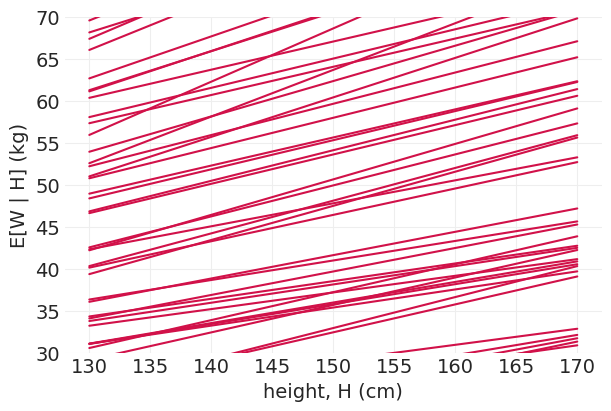

In [9]:


n_simulations = 100

alphas = np.random.normal(0, 10, n_simulations)
betas = np.random.uniform(0, 1, n_simulations)  # beta should all be positive

heights = np.linspace(130, 170, 3)

fig, ax = plt.subplots(figsize=(6, 4))
for a, b in zip(alphas, betas):
    weights = a + b * heights
    plt.plot(heights, weights, color='C0')

plt.xlabel("height, H (cm)")
plt.ylabel("E[W | H] (kg)")
plt.ylim((30, 70));


## Simulation-based Validation & Calibration
- Simulate data with varying parameters
- Vary data-generating parameters (e.g. slope) that are analogous to the model; make sure the estimator tracks
- Make sure that at large sample sizes, data-generating parameters can be recovered
- Same for confounds/unkowns


In [10]:
linear_regression_inferences = []
linear_regression_models = []

sample_sizes = [1, 2, 10, 20, 50, len(H)]

for sample_size in sample_sizes:
    print(f"Sample size: {sample_size}")
    with pm.Model() as model:
        
        # Mutable data for posterior predictive visualization
        H_ = pm.MutableData("H", H[:sample_size], dims="obs_id")
        
        # Priors
        alpha = pm.Normal("alpha", 0, 10)  # Intercept
        beta = pm.Uniform("beta", 0, 1)  # slope
        sigma = pm.Uniform("sigma", 0, 10)  # Noise variance
        
        # Likelihood
        mu = alpha + beta * H_
        pm.Normal("W_obs", mu, sigma, observed=W[:sample_size], dims="obs_id")
        
        # Sample posterior
        inference = pm.sample(target_accept=.99)
        linear_regression_inferences.append(inference)
        linear_regression_models.append(model)
        

Sample size: 1


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 5 seconds.
There were 31 divergences after tuning. Increase `target_accept` or reparameterize.


Sample size: 2


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


...

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 5 seconds.


Sample size: 200


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 6 seconds.


In [11]:
linear_regression_inferences[0]

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data
	> constant_data

### Test Model Validity with Posterior Predictive Distribution

Below we show:
- how the posterior becomes more specific with more of observations
- how the posterior is "made of lines" -- there are an infinite number of possible lines that can be drawn from the posterior
- confidence intervals can be established to communicate the uncertainty of the posterior's fit to the data

Sampling: [W_obs]


Sample size: 1
Sample size: 2


Sampling: [W_obs]
Sampling: [W_obs]
Sampling: [W_obs]


Sample size: 10
Sample size: 20


Sampling: [W_obs]
Sampling: [W_obs]


Sample size: 50
Sample size: 200


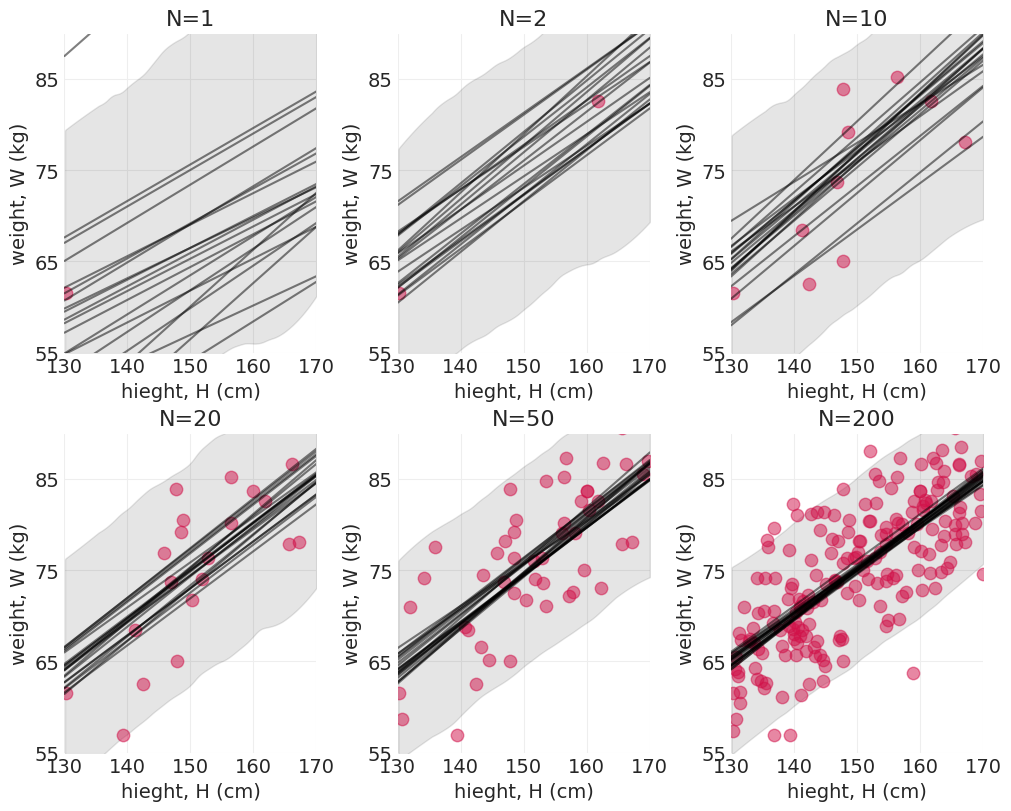

In [12]:
N_SHOW = 20
MIN_WEIGHT = 55
MAX_WEIGHT = 90

def plot_linear_regression_posterior_predictive(
    model, inference,
    min_height=MIN_HEIGHT,
    max_height=MAX_HEIGHT,
    min_weight=MIN_WEIGHT,
    max_weight=MAX_WEIGHT,
    N_SHOW = 20
):
    xs = np.linspace(min_height, max_height, 30)
    H_ = xr.DataArray(xs)
    
    # Sample Posterior Predictive with full range of heights
    with model:
        pm.set_data({'H': H_})
        ppd = pm.sample_posterior_predictive(
            inference,
            var_names=['W_obs'],
            predictions=True,
            return_inferencedata=True,
            progressbar=False
        )
        
    # Plot Posterior Predictive HDI
    az.plot_hdi(H_, ppd.predictions["W_obs"], color='k', fill_kwargs=dict(alpha=.1))
    
    # Plot Posterior
    posterior = inference.posterior
    lines = posterior['alpha'] + posterior['beta'] * H_
    for l in lines[0, :N_SHOW, :]:
        plt.plot(xs, l, color='k', alpha=.5, zorder=20)
       
    # Formatting
    plt.xticks(np.arange(min_height, max_height + 1, 10))
    plt.xlim([min_height, max_height])    
    plt.xlabel("hieght, H (cm)")
    
    plt.ylim([min_weight, max_weight])
    plt.yticks(np.arange(min_weight, max_weight, 10))
    plt.ylabel("weight, W (kg)")
    

fig, axs = plt.subplots(2, 3, figsize=(10, 8))
for ii, (sample_size, model, inference) in enumerate(
        zip(sample_sizes, linear_regression_models, linear_regression_inferences)
    ):
    print(f"Sample size: {sample_size}")
    plt.sca(axs[ii // 3][ii % 3])
    
    # Plot training data
    plt.scatter(H[:sample_size], W[:sample_size], s=80, zorder=20, alpha=.5)
    plot_linear_regression_posterior_predictive(model, inference)
    plt.title(f"N={sample_size}")


## (5) Analyse real data

In [13]:
with pm.Model() as howell_model:

    # Mutable data for posterior predictive / visualization
    H_ = pm.MutableData("H", ADULT_HOWELL.height.values, dims="obs_ids")

    # priors
    alpha = pm.Normal("alpha", 0, 10)  # Intercept
    beta = pm.Uniform("beta", 0, 1)  # Slope
    sigma = pm.Uniform("sigma", 0, 10)  # Noise variance

    # likelihood
    mu = alpha + beta * H_
    pm.Normal("W_obs", mu, sigma, observed=ADULT_HOWELL.weight.values, dims="obs_ids")

    # Sample posterior
    howell_inference = pm.sample(target_accept=.99)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 9 seconds.


In [14]:
howell_inference

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data
	> constant_data

In [15]:
az.summary(howell_inference)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,-43.081,4.255,-50.95,-34.792,0.132,0.093,1046.0,1245.0,1.0
beta,0.570,0.028,0.52,0.625,0.001,0.001,1046.0,1206.0,1.0
sigma,4.279,0.154,3.98,4.559,0.004,0.003,1452.0,1336.0,1.0


### Plot posterior & parameter correlations

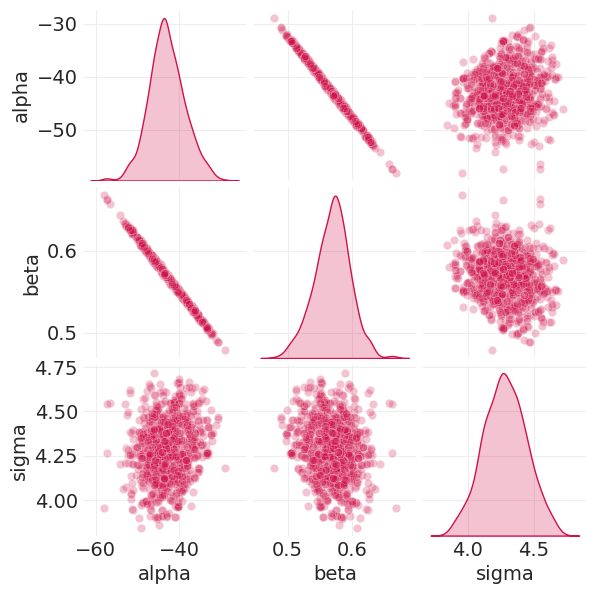

In [16]:
from seaborn import pairplot 

pairplot(
    pd.DataFrame(
        
        {
            "alpha": howell_inference.posterior.sel(chain=0)['alpha'],
            "beta": howell_inference.posterior.sel(chain=0)['beta'],
            "sigma": howell_inference.posterior.sel(chain=0)['sigma'],
        }
    ),
    diag_kind="kde",
    plot_kws={"alpha": .25},
    height=2
);

### Obey The Law: 
- **parameters are not independent**
- **parameters cannot be interpreted in isolation**

Instead...**Push out posterior predictions**

Below, we again show:
- how the posterior is "made of lines" -- there are an infinite number of possible lines that can be drawn from the posterior
- confidence intervals can be established to communicate the uncertainty of the posterior's fit to the data


Sampling: [W_obs]


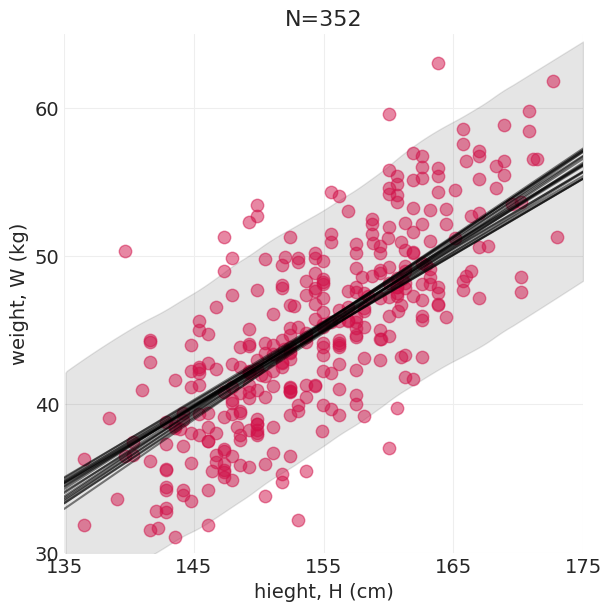

In [17]:
plt.subplots(figsize=(6, 6))
plt.scatter(ADULT_HOWELL.height.values, ADULT_HOWELL.weight.values, s=80, zorder=20, alpha=.5)
plot_linear_regression_posterior_predictive(
    howell_model,
    howell_inference,
    min_height=135,
    max_height=175,
    min_weight=30,
    max_weight=65
)  
plt.title(f"N={len(ADULT_HOWELL)}");

# Homework

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Howell1 dataset
HOWELL = utils.load_data("Howell1")

# Keep only children younger than 13 years
CHILD_HOWELL = HOWELL[HOWELL.age < 13].copy()

# Convert age to months
CHILD_HOWELL["age_months"] = CHILD_HOWELL.age * 12

# Quick check
print(CHILD_HOWELL.shape)
(CHILD_HOWELL.head())



(146, 5)


,height,weight,age,male,age_months
18,121.92,19.617854,12.0,1,144.0
19,105.41,13.947954,8.0,0,96.0
20,86.36,10.489315,6.5,0,78.0
24,109.22,15.989118,7.0,0,84.0
30,114.30,17.860185,11.0,1,132.0


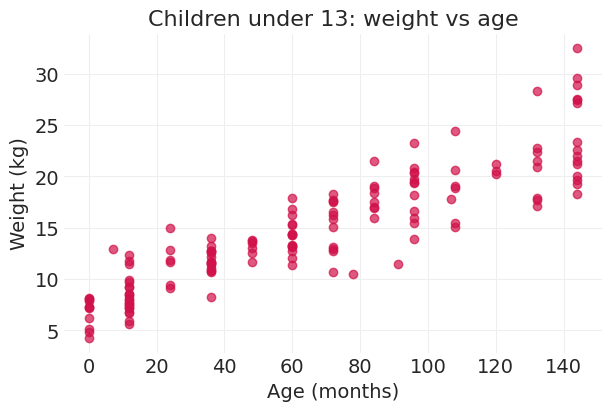

In [19]:
plt.figure(figsize=(6,4))
plt.scatter(CHILD_HOWELL.age_months, CHILD_HOWELL.weight, alpha=0.7)
plt.xlabel("Age (months)")
plt.ylabel("Weight (kg)")
plt.title("Children under 13: weight vs age")
plt.show()


## Step 2: Prior Predictive Simulation (Checking and Justifying Priors)

We perform a prior predictive simulation to evaluate whether the chosen priors imply reasonable values for children’s weights before observing the data.

### Variables

- **Outcome:** weight (kg)  
- **Cause:** age in months  

### Model

We model weight as a linear function of age:

$$
\text{weight}_i \sim \text{Normal}(\mu_i, \sigma)
$$

$$
\mu_i = \alpha + \beta \cdot \text{age\_m\_z}_i
$$

where:

- $\alpha$ is the expected weight at the mean age,
- $\beta$ is the effect of age on weight,
- $\sigma$ represents residual variation,
- $\text{age\_m\_z}$ is standardized age in months.

### Standardization

Age in months is standardized prior to modeling. This ensures that the prior on $\beta$ is numerically stable and interpretable, and allows the slope prior to represent the effect of a one–standard–deviation change in age.

This setup enables meaningful prior predictive checks by translating abstract priors into implied distributions over observable child weights.


Step 2A — Prepare data (standardize age in months)

In [20]:
import numpy as np

x = CHILD_HOWELL["age_months"].to_numpy()
y = CHILD_HOWELL["weight"].to_numpy()

x_mean = x.mean()
x_std  = x.std()

x_z = (x - x_mean) / x_std  # standardized age_months

x_z[0:5]


array([1.731226  , 0.6817803 , 0.28823817, 0.41941888, 1.46886457])

Step 2B — Pick reasonable priors

Kids under 13 might range roughly from a few kg up to maybe ~40–60 kg, so:

α (intercept): around typical kid weight (say ~20 kg), wide uncertainty

β (slope): positive, but not insane

σ (noise): a few kg, but allow more

In [21]:
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

with pm.Model() as m_prior:
    alpha = pm.Normal("alpha", mu=20, sigma=10)      # kg
    beta  = pm.Normal("beta",  mu=0,  sigma=10)      # kg per 1 SD of age
    sigma = pm.Exponential("sigma", 1/5)             # typical scale ~5kg

    mu = alpha + beta * x_z
    weight = pm.Normal("weight", mu=mu, sigma=sigma, observed=None)

    prior_pred = pm.sample_prior_predictive(samples=500, random_seed=123)


Sampling: [alpha, beta, sigma, weight]


Step 2C — Prior predictive check (plot simulated weights)

We want simulated weights to be:

mostly positive

mostly in a plausible range for kids

not like -200 kg or 400 kg 😅

(1, 500, 146) -> (500, 146)


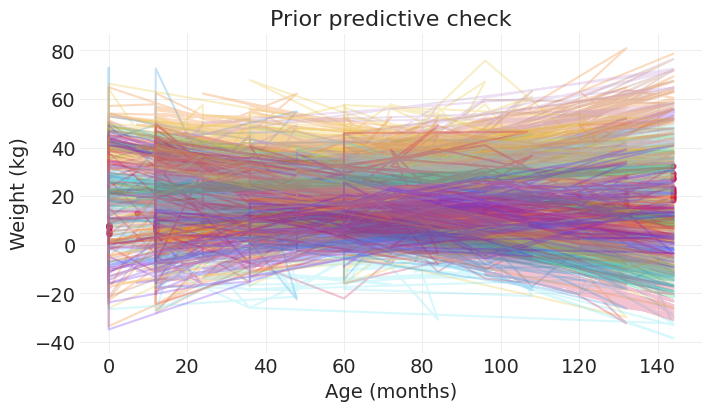

In [22]:
# simulated weights from the prior draws
w_sim = prior_pred.prior["weight"].values   # shape (chain, draw, n)

# flatten chain+draw into one sample dimension
w_sim_flat = w_sim.reshape(-1, w_sim.shape[-1])  # shape (samples, n)

print(w_sim.shape, "->", w_sim_flat.shape)


plt.figure(figsize=(7,4))
plt.plot(x, w_sim_flat[:50].T, alpha=0.25)   # 50 simulated curves
plt.scatter(x, y, s=12, alpha=0.7)           # actual data
plt.xlabel("Age (months)")
plt.ylabel("Weight (kg)")
plt.title("Prior predictive check")
plt.show()


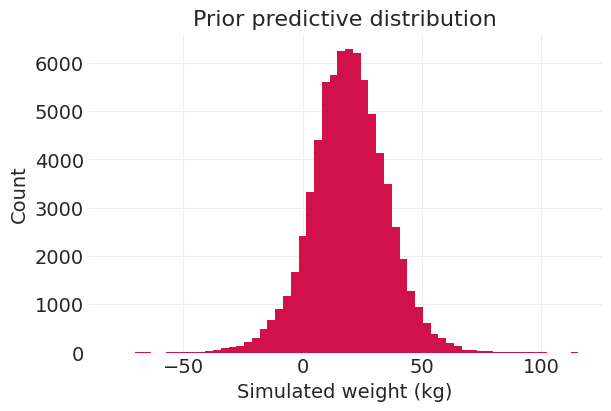

Sim weight min/max: -79.77821049225236 115.51011958249656


In [23]:
plt.figure(figsize=(6,4))
plt.hist(w_sim_flat.flatten(), bins=60)
plt.xlabel("Simulated weight (kg)")
plt.ylabel("Count")
plt.title("Prior predictive distribution")
plt.show()

print("Sim weight min/max:", float(w_sim_flat.min()), float(w_sim_flat.max()))


The initial prior predictive simulation produced implausible values, including negative weights and extremely large weights for children. This indicated overly diffuse priors. Therefore, priors were refined to constrain predictions to biologically plausible ranges while remaining weakly informative.

Sampling: [alpha, beta, sigma, weight]


Extracted shapes:
w_prior: (146, 1000)
alpha: (1000,)
beta: (1000,)
sigma: (1000,)


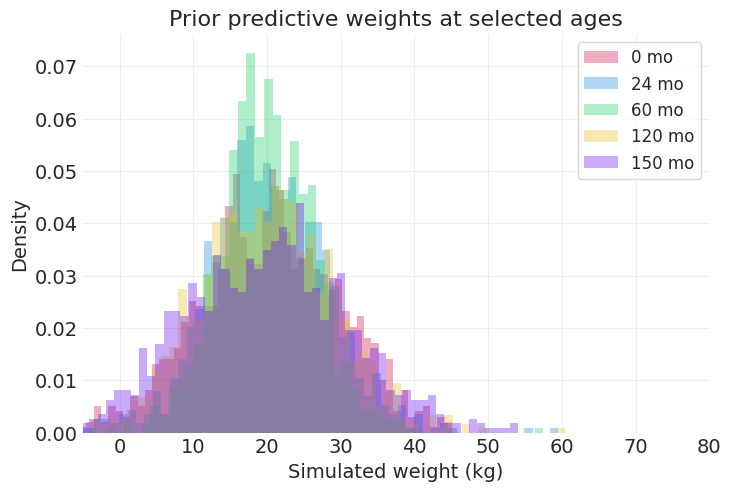

P(weight < 0) under prior: 0.0118
P(weight > 80) under prior: 0.0000


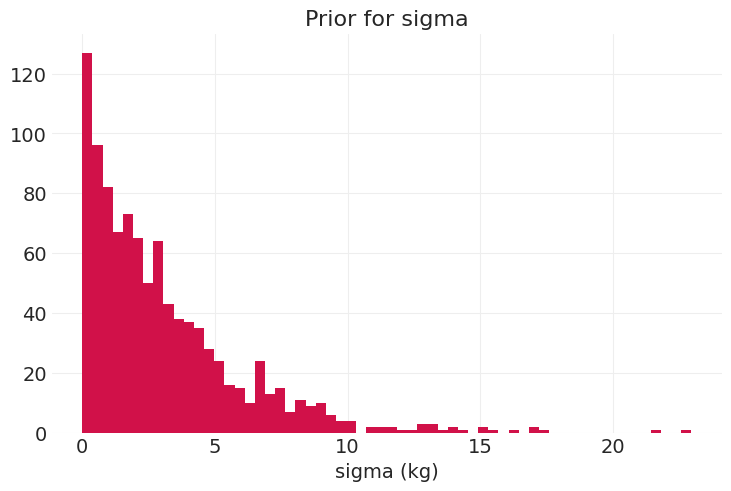

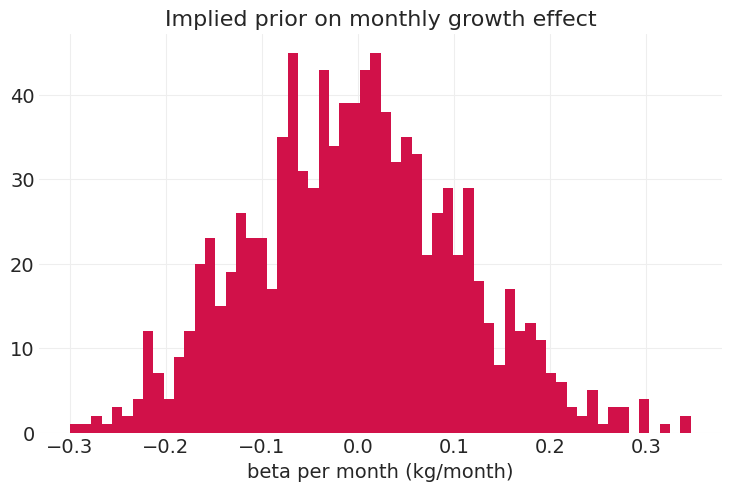

Prior mean(beta per month): -0.002204955061467389
Prior 95% interval(beta per month): [-0.21392887  0.21719531]


In [24]:
# ---------- PRIOR PREDICTIVE CHECK (revised + version-robust) ----------
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az

# Assumes you already defined:
# x (age_months), x_z (standardized), x_std (std in months), and len(x_z) == n

with pm.Model() as m_prior_check:
    alpha = pm.Normal("alpha", mu=20, sigma=5)     # baseline weight at mean age (kg)
    beta  = pm.Normal("beta",  mu=0,  sigma=5)     # kg per 1 SD of age_months
    sigma = pm.Exponential("sigma", 1/3)           # mean ~3 kg

    mu = alpha + beta * x_z

    # prior draws of weights at the observed ages
    weight = pm.Normal("weight", mu=mu, sigma=sigma, shape=len(x_z))

    prior = pm.sample_prior_predictive(1000, random_seed=123)

# ----------------- Helper: flatten samples safely -----------------
def flatten_samples(da, n_obs=None):
    """
    Convert an xarray DataArray of draws into numpy.
    - If it contains observations (n_obs), returns array shaped (n_obs, n_samples)
    - If it's a parameter (no obs dim), returns array shaped (n_samples,)
    Works across different PyMC/ArviZ dimension conventions.
    """
    dims = list(da.dims)

    # Case 1: common (chain, draw)
    if ("chain" in dims) and ("draw" in dims):
        out = da.stack(sample=("chain", "draw"))
        # put obs dimension first (if it exists)
        if n_obs is not None:
            obs_dims = [d for d in out.dims if out.sizes[d] == n_obs and d != "sample"]
            if len(obs_dims) == 1:
                out = out.transpose(obs_dims[0], "sample")
        return out.values

    # Case 2: already has 'sample'
    if "sample" in dims:
        return da.values

    # Infer observation dimension if possible
    obs_dim = None
    if n_obs is not None:
        for d in dims:
            if da.sizes[d] == n_obs:
                obs_dim = d
                break

    # Stack everything except obs_dim into 'sample'
    stack_dims = [d for d in dims if d != obs_dim]
    if len(stack_dims) == 0:
        return da.values

    out = da.stack(sample=tuple(stack_dims))
    if obs_dim is not None and obs_dim in out.dims:
        out = out.transpose(obs_dim, "sample")
    return out.values

# ----------------- Extract prior draws -----------------
# Your version has only group 'prior', so use prior.prior[...]
w_prior = flatten_samples(prior.prior["weight"], n_obs=len(x_z))  # (n, samples) expected
alpha_prior = flatten_samples(prior.prior["alpha"])              # (samples,)
beta_prior  = flatten_samples(prior.prior["beta"])
sigma_prior = flatten_samples(prior.prior["sigma"])

# Ensure weights are shaped (n, samples)
if w_prior.shape[0] != len(x_z) and w_prior.shape[-1] == len(x_z):
    w_prior = w_prior.T

print("Extracted shapes:")
print("w_prior:", w_prior.shape)         # (n, samples)
print("alpha:", alpha_prior.shape)       # (samples,)
print("beta:", beta_prior.shape)
print("sigma:", sigma_prior.shape)

# ----------------- Plots + summary checks -----------------
# Plot implied weight distributions at a few ages
ages_to_show = [0, 24, 60, 120, 150]  # months
idxs = [np.argmin(np.abs(x - a)) for a in ages_to_show]

plt.figure()
for a, i in zip(ages_to_show, idxs):
    plt.hist(w_prior[i, :], bins=60, alpha=0.35, density=True, label=f"{a} mo")
plt.xlim(-5, 80)
plt.xlabel("Simulated weight (kg)")
plt.ylabel("Density")
plt.title("Prior predictive weights at selected ages")
plt.legend()
plt.show()

# How often are weights clearly implausible?
p_neg = (w_prior < 0).mean()
p_hi  = (w_prior > 80).mean()
print(f"P(weight < 0) under prior: {p_neg:.4f}")
print(f"P(weight > 80) under prior: {p_hi:.4f}")

# Sigma prior
plt.figure()
plt.hist(sigma_prior, bins=60)
plt.xlabel("sigma (kg)")
plt.title("Prior for sigma")
plt.show()

# Translate beta prior to kg/month
beta_month_prior = beta_prior / x_std

plt.figure()
plt.hist(beta_month_prior, bins=60)
plt.xlabel("beta per month (kg/month)")
plt.title("Implied prior on monthly growth effect")
plt.show()

print("Prior mean(beta per month):", beta_month_prior.mean())
print("Prior 95% interval(beta per month):", np.quantile(beta_month_prior, [0.025, 0.975]))


Your priors generate child weights mostly between ~5 and ~40 kg across the ages you plotted, with some tail out to ~60 kg — that’s plausible for kids under 13.

You get P(weight < 0) ≈ 0.0118 (about 1.2% of simulated weights are negative). That’s small, and it happens because a Normal likelihood allows negative values in the tail.

You get P(weight > 80) = 0, so the prior is not producing absurdly huge children.

alpha ~ Normal(20, 5) puts most baseline child weights around ~10–30 kg at mean age (reasonable).

beta ~ Normal(0, 5) is weakly informative; when converted to kg/month (divide by x_std), it mostly implies modest monthly changes, matching your “implied prior on monthly growth effect” plot.

sigma ~ Exponential(1/3) concentrates on a few kg of residual variation, with heavier tails allowed.

In [25]:
import pymc as pm

with pm.Model() as m_prior_refined:
    alpha = pm.Normal("alpha", mu=20, sigma=5)     # kg at mean age (since x_z is centered)
    beta  = pm.Normal("beta",  mu=0,  sigma=5)     # kg per 1 SD of age_months
    sigma = pm.Exponential("sigma", 1/3)           # mean ~3 kg

    mu = alpha + beta * x_z

    # simulate weights for each observed x_z value
    weight = pm.Normal("weight", mu=mu, sigma=sigma, shape=len(x_z))

    prior_pred_refined = pm.sample_prior_predictive(500, random_seed=123)


Sampling: [alpha, beta, sigma, weight]


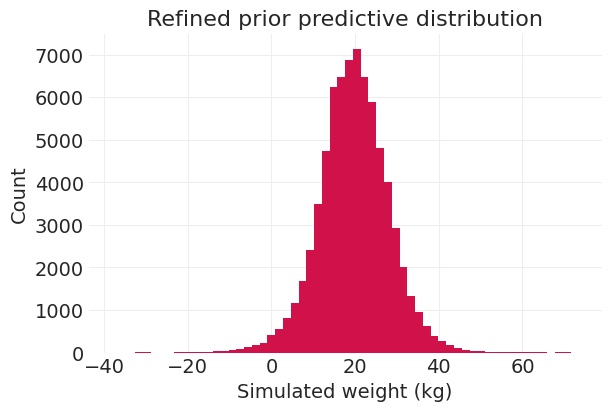

min/max: -38.11732250369517 73.35749591228938


In [26]:
w_sim = prior_pred_refined.prior["weight"].values
w_sim_flat = w_sim.reshape(-1, w_sim.shape[-1])

plt.figure(figsize=(6,4))
plt.hist(w_sim_flat.flatten(), bins=60)
plt.xlabel("Simulated weight (kg)")
plt.ylabel("Count")
plt.title("Refined prior predictive distribution")
plt.show()

print("min/max:", w_sim_flat.min(), w_sim_flat.max())


Although the Normal likelihood allows small probability mass on negative weights, the prior predictive distribution places negligible probability on such values. Given the simplicity of the model and the dominance of plausible mass, this was deemed acceptable.

# Step 3 :Fit Bayesian regression (PyMC)

In [27]:
import pymc as pm
import arviz as az
import numpy as np

with pm.Model() as m_fit:
    # refined priors (from Step 2)
    alpha = pm.Normal("alpha", mu=20, sigma=5)
    beta  = pm.Normal("beta",  mu=0,  sigma=5)   # kg per 1 SD of age_months
    sigma = pm.Exponential("sigma", 1/3)

    mu = alpha + beta * x_z

    # likelihood with observed data
    weight = pm.Normal("weight", mu=mu, sigma=sigma, observed=y)

    trace = pm.sample(2000, tune=2000, chains=4, target_accept=0.9, random_seed=123)


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 1 seconds.


### Quick diagnostics


In [28]:
az.summary(trace, var_names=["alpha", "beta", "sigma"])


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,14.704,0.210,14.309,15.090,0.002,0.002,8755.0,5657.0,1.0
beta,5.106,0.213,4.708,5.508,0.002,0.002,7547.0,5855.0,1.0
sigma,2.555,0.154,2.262,2.834,0.002,0.001,7882.0,5637.0,1.0


Good signs:

r_hat close to 1.00

effective sample size not tiny

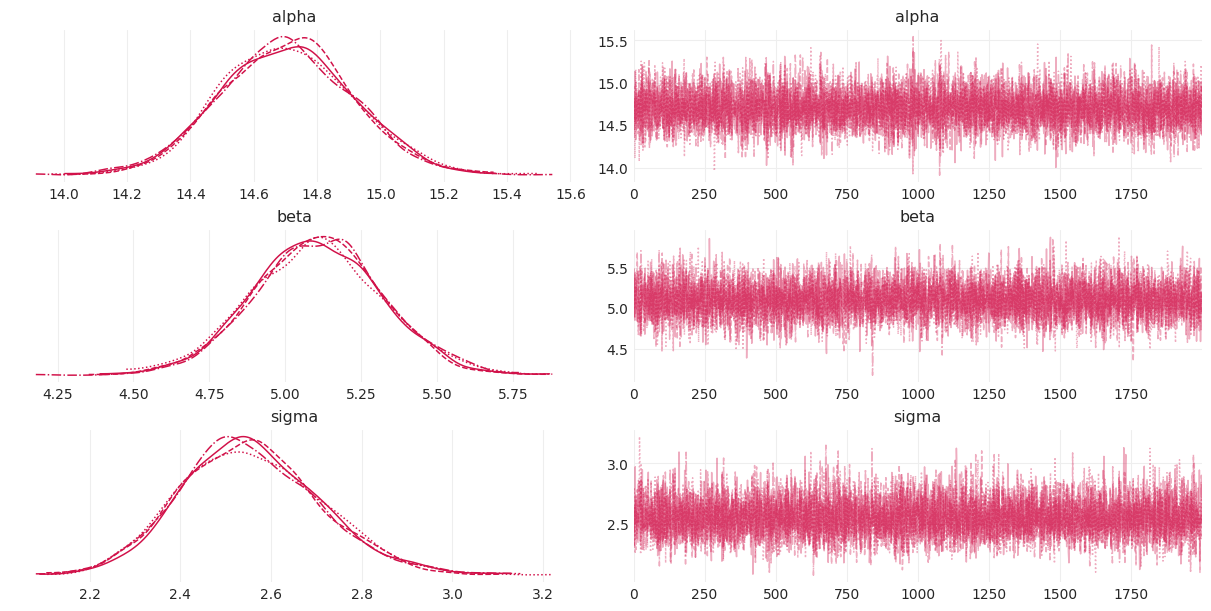

In [29]:
az.plot_trace(trace, var_names=["alpha", "beta", "sigma"])
plt.show()

## Step 3C: Convert the Slope to an Effect per Month

In the fitted model, the coefficient $\beta$ represents the effect of a one–standard–deviation increase in age (in months), because age was standardized prior to modeling.

That is,

$$
x_z = \frac{x - \bar{x}}{s_x}
$$

where:

- $x$ is age in months,
- $\bar{x}$ is the mean age,
- $s_x$ is the standard deviation of age in months.

The linear predictor is therefore:

$$
\mu = \alpha + \beta x_z
     = \alpha + \beta \frac{x - \bar{x}}{s_x}
$$

To obtain the effect of a **one-month increase in age**, we differentiate with respect to $x$:

$$
\beta_{\text{month}} = \frac{\beta}{s_x}
$$

Thus, posterior samples of $\beta$ are divided by the standard deviation of age in months to express the causal effect in units of **kilograms per month**.


In [30]:
beta_samples = trace.posterior["beta"].values.reshape(-1)
beta_per_month = beta_samples / x_std

print("Posterior mean (kg/month):", beta_per_month.mean())
print("90% credible interval:", np.quantile(beta_per_month, [0.05, 0.95]))
print("95% credible interval:", np.quantile(beta_per_month, [0.025, 0.975]))


Posterior mean (kg/month): 0.11162688290609839
90% credible interval: [0.10405852 0.11942912]
95% credible interval: [0.10243886 0.12083756]


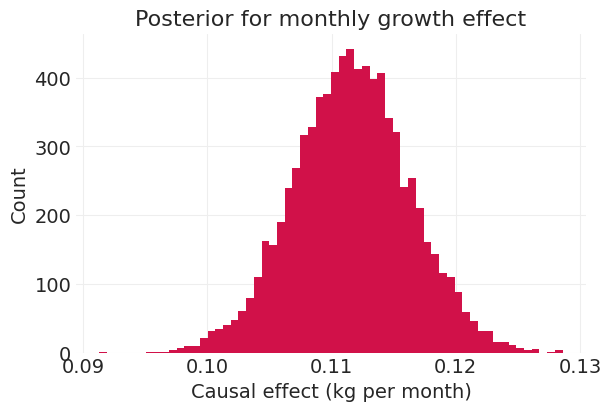

In [31]:
plt.figure(figsize=(6,4))
plt.hist(beta_per_month, bins=60)
plt.xlabel("Causal effect (kg per month)")
plt.ylabel("Count")
plt.title("Posterior for monthly growth effect")
plt.show()


## Interpretation

The effect is clearly positive

The uncertainty interval is very narrow

Almost all posterior mass lies well above zero



Older children weigh more, and the data strongly support this relationship.

this result suggests that an additional month of growth increases expected body weight by roughly 0.11 kg, assuming no unmeasured confounding and that the linear approximation is reasonable over the observed age range.

A 95% credible interval means there is a 95% probability that the true parameter value lies within this range, given the data and model.


Given the data and model, there is a 95% probability that the true monthly weight gain lies between 0.102 and 0.121 kg.

##### ⚠️ How this differs from a confidence interval (important!)


Frequentist confidence interval (NOT what you used)

A 95% confidence interval does not mean:

❌ “95% probability the parameter is in the interval”

Instead it means:

If we repeated the experiment infinitely many times, 95% of such intervals would contain the true value.

That’s about the procedure, not the parameter.

# Possibly also simulate priors to choose best option

Sampling: [alpha, beta, sigma, w]
Sampling: [alpha, beta, sigma, w]
Sampling: [alpha, beta, sigma, w]
Sampling: [alpha, beta, sigma, w]


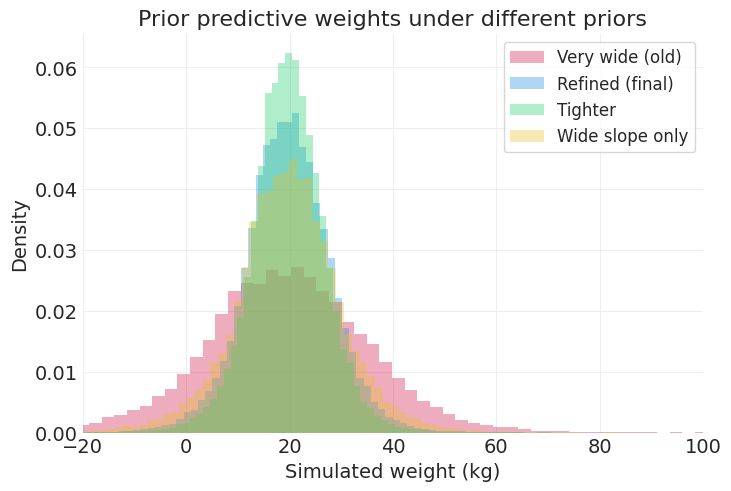

In [33]:
import numpy as np
import pymc as pm
import matplotlib.pyplot as plt

def simulate_prior_weights(alpha_sigma, beta_sigma, sigma_mean, samples=500, seed=123):
    """
    Returns a 1D numpy array of simulated weights pooled across ages and draws.
    Priors:
      alpha ~ Normal(20, alpha_sigma)
      beta  ~ Normal(0,  beta_sigma)   (on z-scale)
      sigma ~ Exponential(1/sigma_mean)
    """
    with pm.Model() as m:
        alpha = pm.Normal("alpha", mu=20, sigma=alpha_sigma)
        beta  = pm.Normal("beta",  mu=0,  sigma=beta_sigma)
        sigma = pm.Exponential("sigma", 1/sigma_mean)

        mu = alpha + beta * x_z
        w  = pm.Normal("w", mu=mu, sigma=sigma, shape=len(x_z))

        prior = pm.sample_prior_predictive(samples=samples, random_seed=seed)

    # Extract w from 'prior' group and flatten across obs + draws
    w_da = prior.prior["w"]
    # stack safely without naming collisions:
    if ("chain" in w_da.dims) and ("draw" in w_da.dims):
        w_flat = w_da.stack(sample=("chain","draw")).values
    else:
        # fallback: just flatten everything
        w_flat = w_da.values

    w_flat = np.asarray(w_flat).reshape(-1)  # pooled weights
    return w_flat

# Define a few prior combinations to compare
prior_sets = [
    {"name": "Very wide (old)",     "alpha_sigma": 10, "beta_sigma": 10, "sigma_mean": 5},
    {"name": "Refined (final)",     "alpha_sigma": 5,  "beta_sigma": 5,  "sigma_mean": 3},
    {"name": "Tighter",             "alpha_sigma": 4,  "beta_sigma": 4,  "sigma_mean": 3},
    {"name": "Wide slope only",     "alpha_sigma": 5,  "beta_sigma": 8,  "sigma_mean": 3},
]

plt.figure()
for p in prior_sets:
    w = simulate_prior_weights(p["alpha_sigma"], p["beta_sigma"], p["sigma_mean"], samples=500, seed=123)
    plt.hist(w, bins=80, alpha=0.35, density=True, label=p["name"])

plt.xlim(-20, 100)
plt.xlabel("Simulated weight (kg)")
plt.ylabel("Density")
plt.title("Prior predictive weights under different priors")
plt.legend()
plt.show()


Figure  compares prior predictive distributions of child weight under several plausible prior specifications. Very diffuse priors produce unrealistically wide predictive distributions, assigning substantial probability to implausible weights. In contrast, the refined priors concentrate predictions within biologically reasonable ranges while remaining sufficiently flexible. This comparison supports the final prior choice as weakly informative and appropriate for the scale of the data.